# 00 | A different lens on an asset
### Alternative data, climate and geospatial foundations
**15 minutes · Basic Python and pandas assumed; no geospatial or climate background needed**

You are helping a private-markets team review a portfolio of buildings and infrastructure.
A spreadsheet tells you the sector and capital invested. What else would you want to know about the places where those assets operate?

**By the end:** distinguish a measurement from a proxy; explain why location links datasets; frame a spatial question using familiar portfolio analysis.

> All assets and climate values in our portfolio case are **fictional teaching data** at real-world coordinates near Houston. They describe no actual properties or local climate. One separate satellite image is a real file used to examine raster structure.

## 1. What makes data “alternative”?
In this class, alternative data means information outside the conventional financial statements and transaction records used by an analyst. The boundary depends on the team: an engineer's routine sensor reading can be an investor's alternative dataset.

| Example | What it directly records | Possible question | What it cannot establish alone |
|---|---|---|---|
| Satellite image | Reflected or emitted energy recorded by a sensor | Has land cover around a site changed? | Revenue, occupancy, or causation |
| Building footprints | Mapped outlines | Where is the physical exposure? | Exact ownership or replacement cost |
| Temperature history | Observed or estimated temperature over time | How often is a threshold exceeded? | Asset damage or future losses |
| Mobility counts | Recorded device activity | Has activity around a site changed? | All visitors, spending, or a representative population |

**Discuss (2 minutes):** Would a brighter night-time image mean a more profitable company? Name two competing explanations.

## 2. Build on the Python you know
We assume you can import a package, filter a DataFrame, group rows and read a plot. Our focus is what changes when records have **geometry** and measurements have **space and time dimensions**.

GeoPandas extends tables with geometry; Rasterio reads spatial grids; xarray works with named multidimensional arrays. We introduce each as needed. Run cells in order and use **Restart Kernel and Run All** after changes to check reproducibility. Saved outputs and the `html` folder are available for reference.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the project root or a subfolder.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/assets.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Keep the notebooks and data folders together; open this project in Jupyter.')
DATA = ROOT / 'data'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})
print('Ready. Core lessons use bundled local data; no API key needed.')

Matplotlib is building the font cache; this may take a moment.


Ready. Core lessons use bundled local data; no API key needed.


In [2]:
assets = pd.read_csv(DATA / 'assets.csv')  # A DataFrame is a table.
display(assets[['asset_id','asset_name','sector','equity_usd_m']].head())
print(f'{len(assets)} fictional assets; total equity ${assets.equity_usd_m.sum():.0f} million')

,asset_id,asset_name,sector,equity_usd_m
0,A01,Bay warehouse,Logistics,20
1,A02,Canal apartments,Housing,35
2,A03,Cedar logistics,Logistics,28
3,A04,Delta solar,Energy,18
4,A05,Elm housing,Housing,42


12 fictional assets; total equity $341 million


## 3. Inspect the portfolio before adding another dataset
The familiar pandas filter below selects a sector. Compare `"Housing"` and `"Logistics"`: would one climate indicator answer the same operational question for both?
`equity_usd_m` means millions of US dollars invested as equity in this fictional example; it is not a loss estimate or property value.

In [3]:
sector_to_view = 'Housing'  # TRY: 'Logistics' or 'Energy'
display(assets.loc[assets.sector == sector_to_view,
                   ['asset_name','sector','equity_usd_m']])

,asset_name,sector,equity_usd_m
1,Canal apartments,Housing,35
4,Elm housing,Housing,42
8,Ivy apartments,Housing,25


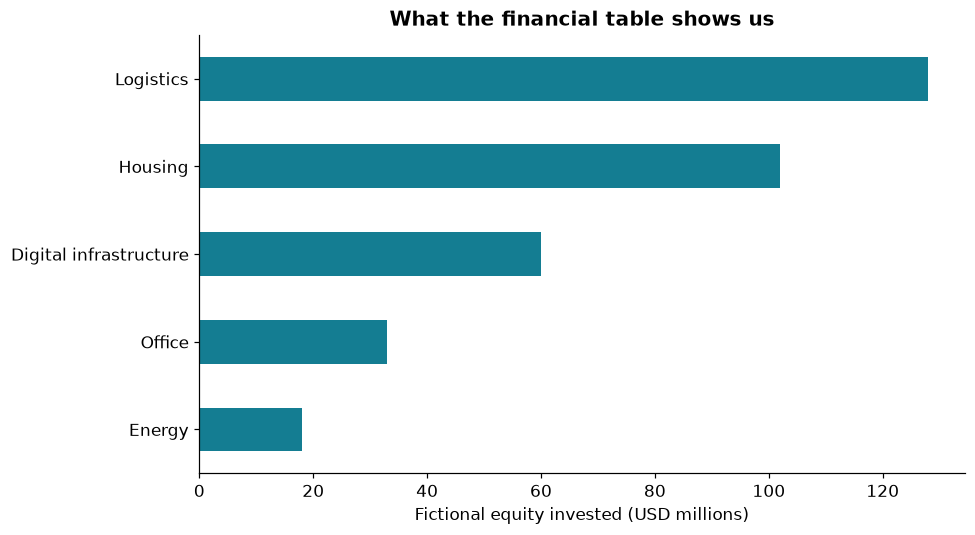

In [4]:
by_sector = assets.groupby('sector').equity_usd_m.sum().sort_values()
ax = by_sector.plot.barh(color='#147d92')
ax.set(xlabel='Fictional equity invested (USD millions)', ylabel='',
       title='What the financial table shows us')
plt.tight_layout()
plt.show()

## 4. From a question to evidence
**Question → location → measurement → quality check → comparison → decision to investigate.**

Before using a new dataset ask: Who produced it? When? What area and population does it cover? What are its units? What is missing? Are the dates and locations aligned with our asset? Can we explain the link to operations? Do we have permission to use it?

**Exit ticket:** Write one operational question about an asset, one useful alternative dataset, and one reason that dataset could mislead you.

**Coding extension:** calculate each sector's share of total equity with pandas. Explain why its share of asset count may differ, and which denominator you would use for your question.

Next: open **01_Data_Formats_and_First_Map.ipynb**. We will turn two spreadsheet columns into geometry.